# Загрузка датасета

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv("hf://datasets/RicardoQi/lenta_ru_news/lenta-ru-news.csv")

/tmp/ipykernel_3103/2475450653.py:1: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("hf://datasets/RicardoQi/lenta_ru_news/lenta-ru-news.csv")


Распределение классов

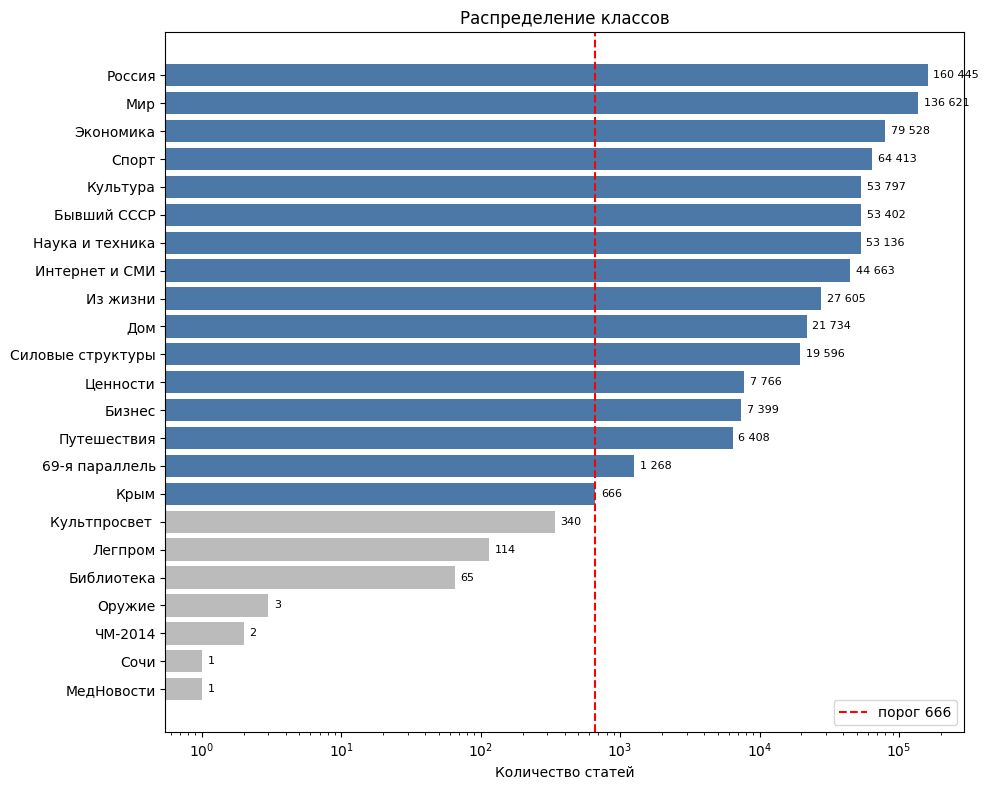

In [6]:
counts = df['topic'].value_counts()
names = counts.index[::-1]
vals = counts.values[::-1]
colors = ['#4C78A8' if v >= 666 else '#BBBBBB' for v in vals]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(names, vals, color=colors)
ax.set_xscale('log')
ax.axvline(666, color='red', linestyle='--', label='порог 666')
for i, v in enumerate(vals):
    ax.text(v * 1.1, i, f'{v:,}'.replace(',', ' '), va='center', fontsize=8)
ax.set_xlabel('Количество статей')
ax.set_title('Распределение классов')
ax.legend()
plt.tight_layout()

# Удаление очень редких топиков

In [7]:
topics = df['topic'].value_counts()
topics_yes = topics[topics>=666].index
df = df[df['topic'].isin(topics_yes)].reset_index(drop = True)

# Удаление нанов в text и topic

In [8]:
df = df.dropna(subset = ['text','topic'])

# Урезание датасета

In [9]:
from sklearn.model_selection import train_test_split
df_sample,_ = train_test_split(df,train_size= 100000,stratify = df['topic'],random_state=42)

In [10]:
df_classic = df_sample.copy()
df_bert = df_sample[['text', 'topic']].copy()

# Обработка текстов статей

In [11]:
import re
def text_clean(text):
  text = str(text).lower() # нижний регистр
  re.sub(r'https?://\S+|www\.\S+', ' URLTOKEN ', text)#замена ссылок
  text = re.sub(r'\d+',' numtoken ',text)#замена цифр
  text = re.sub(r'[^а-яёa-z\s]',' ',text)# убираем все другие символы кроме кириллицы и латиницы
  text = re.sub(r'\s+',' ',text)# лишние пробелы
  return text
df_classic['text_clean'] = df_classic['text'].apply(text_clean)

# Лемматизация текстов

In [12]:
!pip install pymorphy3 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 75.8 MB/s eta 0:00:00


In [13]:
import pymorphy3
all_word = ''.join(df_classic['text_clean']).split()
unique = set(all_word)
morph = pymorphy3.MorphAnalyzer()
lemma_dict = {word: morph.parse(word)[0].normal_form for word in unique}
def lemmatize(text):
  return ' '.join(lemma_dict.get(word,word) for word in text.split())
df_classic['text_lemma'] = df_classic['text_clean'].apply(lemmatize)

# Создание тестового датасета

In [14]:
_,testdf = train_test_split(df,test_size=0.2,stratify = df['topic'],random_state=42)

## предобработка для классики

In [15]:
testdf['text_lemma'] = testdf['text'].apply(text_clean).apply(lemmatize)

# Сохранение датасетов

In [16]:
import os
from pathlib import Path
put = Path('/content/drive/MyDrive') # поменять на любой удобный путь
put.mkdir(exist_ok=True)
df_classic[['text_lemma', 'topic']].to_parquet(put / 'classic_data.parquet')
df_bert[['text', 'topic']].to_parquet(put / 'bert_data.parquet')
testdf[['text','topic','text_lemma']].to_parquet(put/'test_data.parquet')